In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv('student_scores.csv')
data.head()

,hours,scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


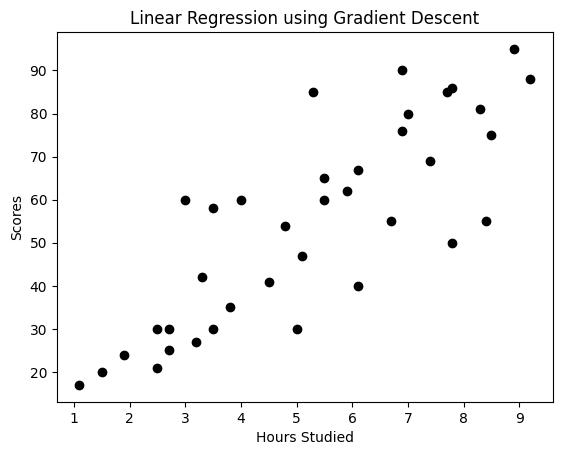

In [13]:
plt.scatter(data.hours, data.scores, color="black")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.title("Linear Regression using Gradient Descent")
plt.show()

In [ ]:
def gradient_descent(m_now, b_now, points, L):
    #m_now - súčasný odhad sklonu priamky m
    #b_now - súčasný odhad y-priesečníka b
    #points - body
    #L - learning rate (rýchlosť učenia, ako veľké kroky gradient descent robí)
    #Cieľ: upraviť m a b, aby sa minimalizovala chyba predikcie.

    #m_gradient a b_gradient budú uchovávať, ako veľmi treba zmeniť m a b
    m_gradient = 0
    b_gradient = 0

    n = len(points)     #počet dátových bodov

    #pre každý bod v dátach
    for i in range(n):
        x = points.iloc[i].hours        #hodiny
        y = points.iloc[i].scores       #skóre

        #chybu vypočítame ako rozdiel medzi skutočnou hodnotou a predikovanou
        error = y - (m_now * x + b_now)

        #gradienty: určujú, ako moc treba meniť m a b
        #Gradient pre m = hovorí, ako veľmi zmeniť sklon podľa chyby a hodnoty x.
        #Gradient pre b = hovorí, ako veľmi zmeniť priesečník podľa chyby (x nemá vplyv).
        m_gradient += -(2/n) * x * error  #pre m: viac ovplyvňuje hodnota x
        b_gradient += -(2/n) * error      #pre b: nezávisí na x, len na chybe

        
        
    #aktualizujeme parametre posunutím proti gradientu
    m = m_now - L * m_gradient
    b = b_now - L * b_gradient

    return m, b


9.743939981663242 1.8479187779846051


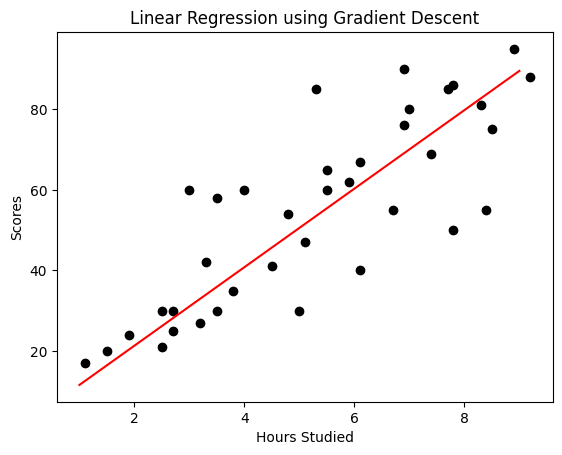

In [10]:
m = 0
b = 0
L = 0.0001
epochs = 1000

for i in range(epochs):
    m, b = gradient_descent(m, b, data, L)
    
print(m, b)

plt.scatter(data.hours, data.scores, color="black")

x_values = list(range(int(data.hours.min()), int(data.hours.max()) + 1))
y_values = [m * x + b for x in x_values]

plt.plot(x_values, y_values, color="red")  # regression line
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.title("Linear Regression using Gradient Descent")
plt.show()
